# 11 — Conducción y drible de balón

Tercera tarea del catálogo, con la cinemática simple del kit (sin física, sin ruido, observación completa).
Código: `src/dribbling_env.py` (entorno, controlador guionado, representaciones), `src/task_train.py`
(entrenamiento) y `src/task_analysis.py` (resúmenes con IC bootstrap).

**MDP** $\langle \mathcal{S}, \mathcal{A}, \mathcal{P}, R, \gamma \rangle$:

- **Inicio:** jugador en $x_0 \sim U[-40, -10]$, $y_0 \sim U[-20, 20]$ m, rumbo $U(-180^\circ, 180^\circ)$; balón
  0.5 m adelante (empieza en posesión).
- **Acciones (4):** `KICK 25` (balón +2 m en la dirección del jugador, solo si $d_b \le 0.8$ m; si no, no hace nada),
  `DASH 80` (jugador +0.8 m), `TURN ±35` (exacto). Sin colisión jugador–balón.
- **Transición:** determinista.
- **Recompensa:** $\Delta x$ del balón $- 0.1$ por paso; $-30$ y fin si $d_b > 4$ m (pérdida) o el balón o el jugador
  salen de la cancha; $+50$ y fin al avanzar el balón 30 m en $x$ (éxito).
- **$\gamma = 0.99$**, $T_{max} = 100$.
- **Estados (36):** $d_b$ {≤ 0.8, (0.8, 2], (2, 4]} m × $\theta_b$ {frente ±17.5°, der., izq.} × $\theta_g$ (rumbo al
  centro del arco) {frente ±17.5°, der., izq., atrás $|\theta| > 90^\circ$}. 0.8 m es el radio de posesión (el mismo
  del `KICK`), 2 m es un `KICK` y 4 m la pérdida; ±17.5° es la mitad del giro de 35°.
- **Sin $d_g$:** la distancia al arco queda entre ~32 y ~92 m en todo episodio y no cambia la mejor acción (no hay
  riesgo de salir por la línea de fondo), así que no la incluimos. Con $y_0 \in [-20, 20]$ y un error de rumbo
  ≤ 17.5°, el desvío lateral en 30 m es ≤ 9.5 m: tampoco hay riesgo de salir por la banda si el agente conduce bien.
- **Criterio:** avance > 30 m con control en > 80 % de los episodios.

In [1]:
import os, json
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
os.chdir("/workspace") if os.path.isdir("/workspace/src") else None
from src import plots, dribbling_env as de
from src.task_analysis import load_condition
from src.task_train import get_task, run_episode
from src.agents import AGENTS

ART = "notebooks/artifacts"
RUNS = f"{ART}/runs_dribbling"
DIAG = f"{ART}/runs_dribbling_diag"
summary = json.load(open(f"{ART}/dribbling_summary.json"))["conditions"]
alphas = json.load(open(f"{ART}/dribbling_alphas.json"))
disc = de.default_discretizer()
spec = get_task("dribbling")
SHORT = ["KICK", "DASH", "T+35", "T−35"]
ACOLORS = ["#1baf7a", "#2a78d6", "#eb6834", "#f4a582"]
NAMES = {"d_b": "distancia al balón", "theta_b": "rumbo al balón", "theta_g": "rumbo al arco"}
METHOD_ES = {"qlearning": "Q-Learning", "sarsa": "SARSA", "mc_first_visit": "MC (promedio)",
             "mc_first_visit_alpha": "MC (α constante)"}
COLS = ["qlearning", "sarsa", "mc_first_visit_alpha", "mc_first_visit"]
SCHED_ES = {"eps_const_0.1": "ε const. 0.1", "eps_decay_1_to_0.1": "ε decreciente 1→0.1"}
def pct(x): return f"{100 * x:.1f} %"
def ci(s): return f"{pct(s['mean'])} [{100 * s['ci95'][0]:.1f}, {100 * s['ci95'][1]:.1f}]"

## 1. Cota constructiva: controlador guionado

Todo inicio se puede resolver: en posesión, girar hasta que el arco quede a ±17.5° y patear; sin posesión, girar
hacia el balón y correr. Como el `KICK` manda el balón en la dirección del jugador, la persecución es en línea recta
y el balón nunca se pierde. Lo verificamos sobre los 500 inicios de evaluación y 20 000 inicios aleatorios: el 100 %
es alcanzable (cota constructiva de la tasa de éxito; el guionado **no** es óptimo en pasos ni en retorno).

In [2]:
def scripted(starts):
    env = de.DribblingEnv(seed=0); out = []
    for s in starts:
        obs, _ = env.reset(s); done, ret, disc_ret, g = False, 0.0, 0.0, 1.0
        while not done:
            obs, r, term, trunc, info = env.step(de.scripted_action(obs))
            ret += r; disc_ret += g * r; g *= 0.99; done = term or trunc
        out.append((info["outcome"], env.step_count, ret, disc_ret))
    return out
rows, bound = [], {}
for name, starts in (("evaluación (500, semilla 12345)", de.evaluation_starts(500, 12345)),
                     ("aleatorios (20 000, semilla 99)", de.evaluation_starts(20000, 99))):
    res = scripted(starts)
    succ = np.mean([o == de.SUCCESS for o, *_ in res]); steps = [s for _, s, *_ in res]
    bound[name] = {"success_rate": float(succ), "mean_steps": float(np.mean(steps)), "max_steps": int(max(steps)),
                   "mean_return": float(np.mean([r for *_, r, _ in res])),
                   "mean_discounted_return": float(np.mean([d for *_, d in res]))}
    rows.append(f"| {name} | {pct(succ)} | {np.mean(steps):.1f} | {max(steps)} | {bound[name]['mean_return']:.1f} | {bound[name]['mean_discounted_return']:.1f} |")
json.dump(bound, open(f"{ART}/dribbling_scripted.json", "w"), indent=2, ensure_ascii=False)
display(Markdown("\n".join(["| inicios | éxito | pasos medios | pasos máx. | retorno | retorno descontado G₀ |",
                            "|---|---|---|---|---|---|"] + rows)))

| inicios | éxito | pasos medios | pasos máx. | retorno | retorno descontado G₀ |
|---|---|---|---|---|---|
| evaluación (500, semilla 12345) | 100.0 % | 60.5 | 82 | 75.2 | 46.3 |
| aleatorios (20 000, semilla 99) | 100.0 % | 60.4 | 85 | 75.2 | 46.3 |

## 2. Ablación de exploración (Q-Learning)

Q-Learning, 60 000 episodios, 5 semillas (0–4). $\alpha$ elegido **por separado para cada esquema** de exploración
con un barrido en semillas 5–9 (en tiro a puerta se eligió solo con $\varepsilon$ decreciente y eso confundió la
ablación). Evaluación greedy cada 2 000 episodios sobre 500 inicios fijos; curvas: media de 5 semillas, banda:
mínimo–máximo entre semillas. Como la política greedy oscila (§3),
además del valor final reportamos la media y el peor de las últimas 5 evaluaciones.

α elegidos (barrido por esquema, semillas 5–9):
  mc_first_visit_alpha|eps_const_0.1: 0.1
  mc_first_visit_alpha|eps_decay_1_to_0.1: 0.03
  qlearning|eps_const_0.1: 0.1
  qlearning|eps_decay_1_to_0.1: 0.03
  sarsa|eps_const_0.1: 0.03
  sarsa|eps_decay_1_to_0.1: 0.03


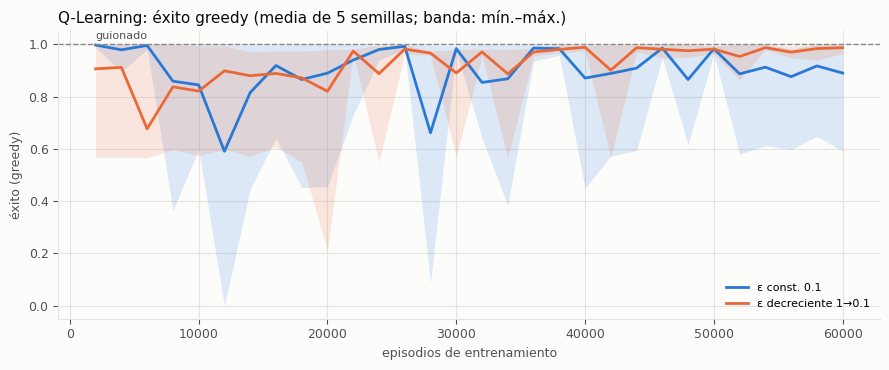

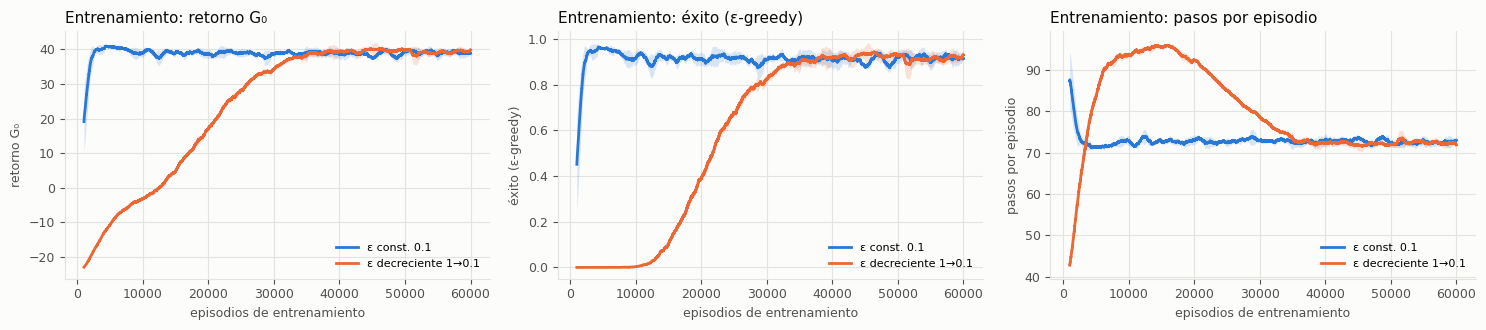

In [3]:
print("α elegidos (barrido por esquema, semillas 5–9):")
for k, v in sorted(alphas["alphas"].items()):
    if "|" in k: print(f"  {k}: {v:g}")
q_runs = {c: load_condition(f"{RUNS}/dribbling_qlearning_{c}") for c in ("eps_const_0.1", "eps_decay_1_to_0.1")}
fig, ax = plt.subplots(figsize=(9, 3.8))
plots.plot_task_eval_curves(q_runs, "default", ax=ax, labels=SCHED_ES, ylabel="éxito (greedy)",
                            refs={"guionado": 1.0}, title="Q-Learning: éxito greedy (media de 5 semillas; banda: mín.–máx.)")
fig.tight_layout(); fig.savefig(f"{ART}/fig_dribbling_ablation.png", dpi=150, bbox_inches="tight"); plt.show()
fig, axes = plt.subplots(1, 3, figsize=(15, 3.4))
for ax, key, ylab in zip(axes, ("discounted_return", "success", "steps"),
                         ("retorno G₀", "éxito (ε-greedy)", "pasos por episodio")):
    plots.plot_training_curve(q_runs, key, window=1000, ax=ax, labels=SCHED_ES, ylabel=ylab,
                              title=f"Entrenamiento: {ylab}", direct_labels=False)
fig.tight_layout(); fig.savefig(f"{ART}/fig_dribbling_training.png", dpi=150, bbox_inches="tight"); plt.show()

## 3. Oscilación de la política greedy

Cada curva es una semilla. En un entorno determinista, la tasa de éxito greedy sube y baja entre evaluaciones.
Las caídas son **timeouts**: la política greedy entra en un ciclo `TURN +35` / `TURN −35` entre dos estados
agregados cuyos valores están casi empatados, y una actualización pequeña basta para invertir la elección.

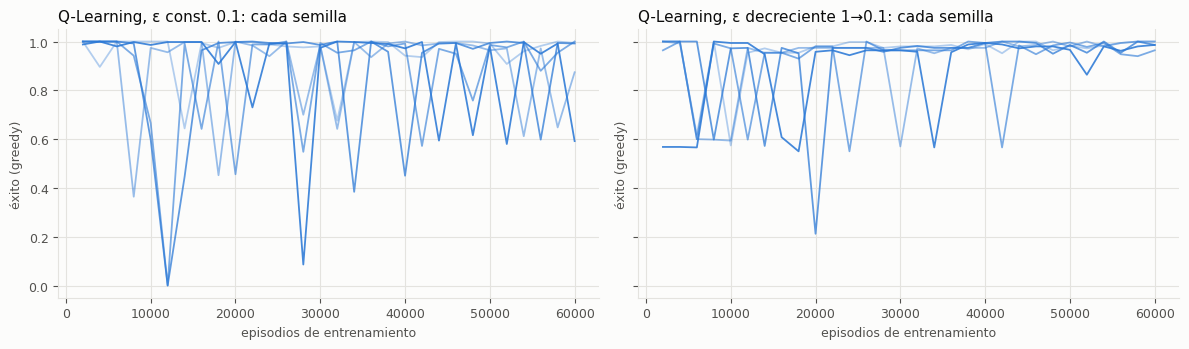

| condición | timeouts (media de evals) | pérdidas | fuera |
|---|---|---|---|
| ε const. 0.1 | 9.3 % | 0.0 % | 0.7 % |
| ε decreciente 1→0.1 | 7.5 % | 0.0 % | 0.1 % |

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6), sharey=True)
for ax, (c, rs) in zip(axes, q_runs.items()):
    for i, r in enumerate(rs):
        x = [e["episode"] for e in r["evals"]]
        ax.plot(x, [e["variants"]["default"]["success_rate"] for e in r["evals"]], color=plots.SERIES[0],
                alpha=0.35 + 0.13 * i, linewidth=1.3)
    plots.style(ax, f"Q-Learning, {SCHED_ES[c]}: cada semilla", "episodios de entrenamiento", "éxito (greedy)")
fig.tight_layout(); fig.savefig(f"{ART}/fig_dribbling_oscillation.png", dpi=150, bbox_inches="tight"); plt.show()
rows = ["| condición | timeouts (media de evals) | pérdidas | fuera |", "|---|---|---|---|"]
for c, rs in q_runs.items():
    ev = [e["variants"]["default"] for r in rs for e in r["evals"]]
    rows.append(f"| {SCHED_ES[c]} | {pct(np.mean([e['timeout_rate'] for e in ev]))} | "
                f"{pct(np.mean([e['lost_rate'] for e in ev]))} | {pct(np.mean([e['out_rate'] for e in ev]))} |")
display(Markdown("\n".join(rows)))

## 4. Política y valor aprendidos

Q-Learning con $\varepsilon$ decreciente, semilla 0, Q-table final: acción greedy y $\hat V(s)$; los estados nunca
visitados en la evaluación final se marcan con "—".

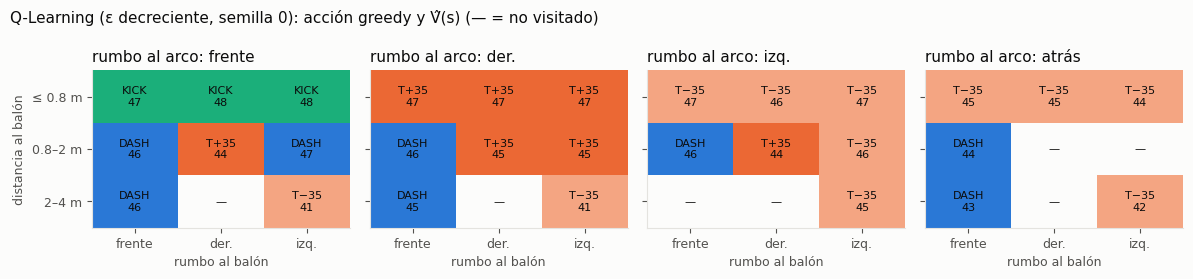

estados visitados por la política greedy en la evaluación: 29 de 36


In [5]:
Q = q_runs["eps_decay_1_to_0.1"][0]["Q"]
env = de.DribblingEnv(seed=0); agent = AGENTS["qlearning"](disc.n_states, 4, seed=0); agent.Q = Q.copy()
visits = np.zeros(disc.n_states, dtype=int)
for s in de.evaluation_starts(500, 12345):
    rec = run_episode(spec, env, agent, disc, 0.0, learn=False, start=s, record=True)
    for t in rec["trajectory"][:-1]:
        th_b = np.degrees(np.arctan2(t["ball"][1] - t["player"][1], t["ball"][0] - t["player"][0])) - t["body_dir"]
        th_g = np.degrees(np.arctan2(-t["player"][1], 52.5 - t["player"][0])) - t["body_dir"]
        visits[disc({"d_b": t["d_b"], "theta_b": th_b, "theta_g": th_g})] += 1
fig = plots.plot_policy_grid(Q.argmax(1), disc, row="d_b", col="theta_b", facet="theta_g", action_short=SHORT,
                             action_colors=ACOLORS, values=Q.max(1), mask=visits == 0, figsize=(12, 2.8), names=NAMES,
                             title="Q-Learning (ε decreciente, semilla 0): acción greedy y V̂(s) (— = no visitado)")
fig.savefig(f"{ART}/fig_dribbling_policy.png", dpi=150, bbox_inches="tight"); plt.show()
print(f"estados visitados por la política greedy en la evaluación: {int((visits > 0).sum())} de {disc.n_states}")

## 5. Trayectorias mientras aprende

Política greedy de copias de la Q-table (Q-Learning, $\varepsilon$ decreciente, semilla 0) sobre los mismos 6 inicios.
Color del balón: resultado; gris: jugador; línea punteada: meta de 30 m de cada episodio.

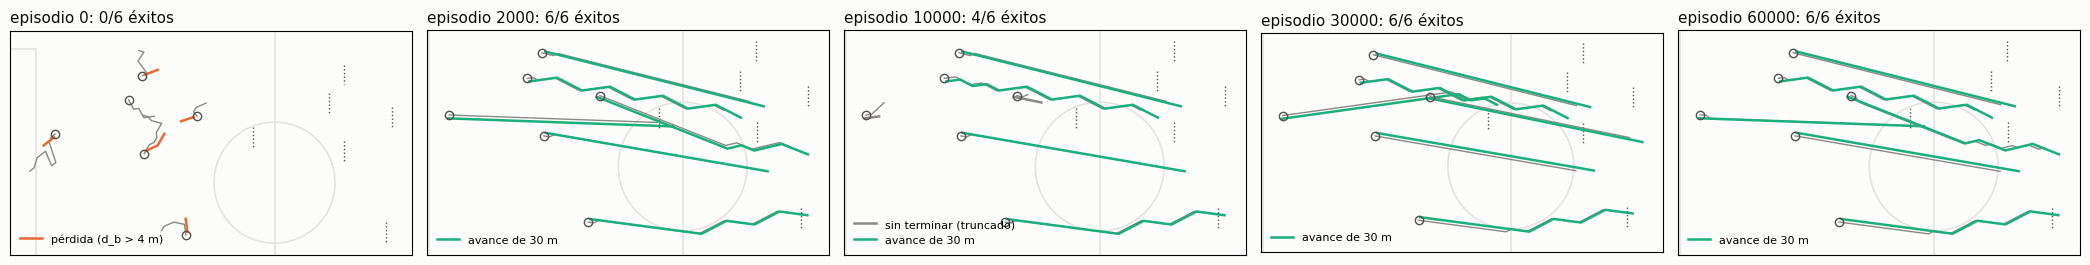

In [6]:
snaps = np.load(f"{RUNS}/dribbling_qlearning_eps_decay_1_to_0.1/seed_0/q_snapshots.npz")
starts = de.evaluation_starts(500, 12345)[:6]
keys = sorted(snaps.files, key=lambda k: int(k.split("_")[1]))
fig, axes = plt.subplots(1, len(keys), figsize=(4.2 * len(keys), 4.4))
for ax, k in zip(axes, keys):
    agent = AGENTS["qlearning"](disc.n_states, 4, seed=0); agent.Q = snaps[k].copy()
    recs = [run_episode(spec, env, agent, disc, 0.0, learn=False, start=s, record=True) for s in starts]
    plots.plot_dribbling_episodes(recs, ax=ax, title=f"episodio {int(k.split('_')[1])}: "
                                  f"{sum(r['success'] for r in recs)}/6 éxitos")
fig.tight_layout(); fig.savefig(f"{ART}/fig_dribbling_learning_traj.png", dpi=150, bbox_inches="tight"); plt.show()

## 6. Criterio de éxito

Éxito greedy (avance de 30 m sin pérdida) al final, media de las últimas 5 evaluaciones y peor de las últimas 5
(media de 5 semillas, IC 95 % bootstrap sobre semillas). Criterio: > 80 %.

In [7]:
rows = ["| método | exploración | α | final | media últimas 5 | peor de últimas 5 | cumple (media últimas 5 > 80 % en cada semilla) |",
        "|---|---|---|---|---|---|---|"]
for name, s in summary.items():
    if s["runs_dir"] != RUNS:
        continue
    v = s["variants"]["default"]
    sched = SCHED_ES["eps_" + name.split("_eps_")[1]]
    alpha = "1/N" if s["algorithm"] == "mc_first_visit" else f"{s['alpha']:g}"
    ok = sum(x > 0.8 for x in v["last5_mean"]["per_seed"])
    rows.append(f"| {METHOD_ES[s['algorithm']]} | {sched} | {alpha} | {ci(v['final'])} | {ci(v['last5_mean'])} | "
                f"{ci(v['last5_worst'])} | {ok}/5 semillas |")
display(Markdown("\n".join(rows)))

| método | exploración | α | final | media últimas 5 | peor de últimas 5 | cumple (media últimas 5 > 80 % en cada semilla) |
|---|---|---|---|---|---|---|
| MC (α constante) | ε const. 0.1 | 0.1 | 27.2 % [4.4, 50.1] | 18.8 % [7.1, 33.8] | 0.0 % [0.0, 0.0] | 0/5 semillas |
| MC (α constante) | ε decreciente 1→0.1 | 0.03 | 39.8 % [12.0, 67.6] | 30.1 % [16.3, 45.7] | 2.6 % [0.0, 7.9] | 0/5 semillas |
| MC (promedio) | ε const. 0.1 | 1/N | 58.8 % [18.8, 98.8] | 70.6 % [52.0, 87.6] | 20.0 % [0.0, 60.0] | 1/5 semillas |
| MC (promedio) | ε decreciente 1→0.1 | 1/N | 92.9 % [86.6, 98.9] | 90.4 % [79.0, 98.9] | 86.6 % [67.6, 98.9] | 4/5 semillas |
| Q-Learning | ε const. 0.1 | 0.1 | 89.0 % [73.0, 99.6] | 89.7 % [83.8, 95.5] | 71.6 % [59.4, 84.0] | 5/5 semillas |
| Q-Learning | ε decreciente 1→0.1 | 0.03 | 98.7 % [97.6, 99.7] | 97.7 % [96.3, 99.0] | 94.2 % [90.1, 97.2] | 5/5 semillas |
| SARSA | ε const. 0.1 | 0.03 | 97.2 % [95.4, 98.3] | 96.8 % [95.8, 97.8] | 92.7 % [87.9, 96.8] | 5/5 semillas |
| SARSA | ε decreciente 1→0.1 | 0.03 | 86.6 % [63.9, 98.7] | 94.3 % [89.8, 97.7] | 82.1 % [60.3, 97.1] | 5/5 semillas |

## 7. Comparación de métodos

Mismos estados, acciones, presupuesto, semillas e inicios; solo cambia la regla de actualización. AUC = media del
éxito greedy a lo largo del entrenamiento (mayor = aprende antes). $\varepsilon$-greedy = éxito del último 10 % del
entrenamiento, con la exploración activa.

| método | exploración | media últimas 5 | AUC | ε-greedy (último 10 %) | pérdidas ε-greedy |
|---|---|---|---|---|---|
| MC (α constante) | ε const. 0.1 | 18.8 % [7.1, 33.8] | 20.4 % [15.4, 25.5] | 13.1 % [12.5, 13.8] | 5.8 % |
| MC (α constante) | ε decreciente 1→0.1 | 30.1 % [16.3, 45.7] | 22.3 % [18.9, 26.6] | 23.7 % [21.8, 26.0] | 5.1 % |
| MC (promedio) | ε const. 0.1 | 70.6 % [52.0, 87.6] | 79.8 % [70.9, 88.7] | 76.4 % [71.2, 81.3] | 1.0 % |
| MC (promedio) | ε decreciente 1→0.1 | 90.4 % [79.0, 98.9] | 70.8 % [57.6, 80.5] | 87.7 % [83.4, 92.3] | 2.4 % |
| Q-Learning | ε const. 0.1 | 89.7 % [83.8, 95.5] | 90.0 % [87.7, 93.0] | 91.6 % [90.6, 92.5] | 0.5 % |
| Q-Learning | ε decreciente 1→0.1 | 97.7 % [96.3, 99.0] | 92.4 % [90.5, 94.3] | 91.9 % [90.6, 92.8] | 0.3 % |
| SARSA | ε const. 0.1 | 96.8 % [95.8, 97.8] | 96.1 % [94.3, 97.9] | 91.2 % [89.7, 92.5] | 0.4 % |
| SARSA | ε decreciente 1→0.1 | 94.3 % [89.8, 97.7] | 76.2 % [73.5, 79.9] | 92.3 % [92.0, 92.6] | 0.4 % |

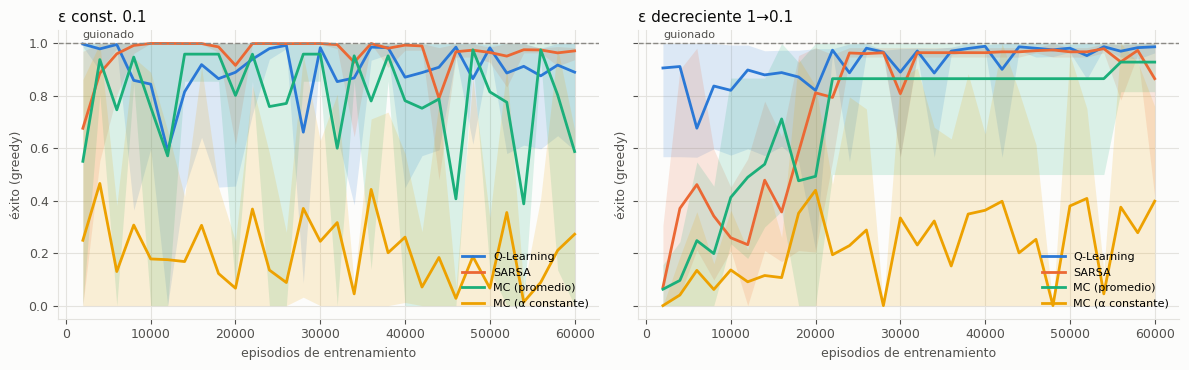

In [8]:
rows = ["| método | exploración | media últimas 5 | AUC | ε-greedy (último 10 %) | pérdidas ε-greedy |",
        "|---|---|---|---|---|---|"]
for name, s in summary.items():
    if s["runs_dir"] != RUNS:
        continue
    v = s["variants"]["default"]
    sched = SCHED_ES["eps_" + name.split("_eps_")[1]]
    runs = load_condition(f"{RUNS}/{name}")
    tail = s["n_episodes"] // 10
    lost = np.mean([np.isin(r["history"]["outcome"][-tail:], [de.LOST, de.OUT]).mean() for r in runs])
    rows.append(f"| {METHOD_ES[s['algorithm']]} | {sched} | {ci(v['last5_mean'])} | {ci(v['auc'])} | "
                f"{ci(s['online_final'])} | {pct(lost)} |")
display(Markdown("\n".join(rows)))
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), sharey=True)
for ax, sched in zip(axes, ("eps_const_0.1", "eps_decay_1_to_0.1")):
    runs = {m: load_condition(f"{RUNS}/dribbling_{m}_{sched}") for m in METHOD_ES}
    plots.plot_task_eval_curves(runs, "default", ax=ax, labels=METHOD_ES, ylabel="éxito (greedy)",
                                refs={"guionado": 1.0}, title=SCHED_ES[sched])
fig.tight_layout(); fig.savefig(f"{ART}/fig_dribbling_methods.png", dpi=150, bbox_inches="tight"); plt.show()

## 8. Diagnósticos

**Agregación de estados (aliasing).** Si la oscilación se debe a que estados distintos comparten casilla, una
representación más fina (245 estados: 5 zonas de $d_b$ y 7 sectores de rumbo para balón y arco, con izquierda y
derecha también detrás) debería reducirla. Ambas representaciones con 120 000 episodios (el doble), $\varepsilon$
decreciente, mismo $\alpha$ elegido.

**Riesgo.** Con $\varepsilon$ constante, los métodos on-policy (SARSA, MC) aprenden el valor de la política que
explora y podrían conducir con más cuidado que Q-Learning. Si es así, la diferencia de pérdidas durante la
exploración debería achicarse al hacer los errores más baratos (radio de pérdida de 8 m en vez de 4 m).

**Agregación (120 000 episodios, ε decreciente):**

| método | 36 estados: media últ. 5 | peor últ. 5 | 245 estados: media últ. 5 | peor últ. 5 |
|---|---|---|---|---|
| Q-Learning | 95.1 % [91.3, 97.7] | 86.0 % [70.2, 95.8] | 100.0 % [100.0, 100.0] | 100.0 % [100.0, 100.0] |
| SARSA | 97.6 % [96.8, 98.4] | 94.0 % [92.3, 95.6] | 100.0 % [100.0, 100.0] | 100.0 % [100.0, 100.0] |
| MC (α constante) | 22.5 % [8.9, 35.0] | 0.0 % [0.0, 0.0] | 36.2 % [24.6, 47.2] | 0.0 % [0.0, 0.0] |
| MC (promedio) | 64.5 % [49.3, 79.7] | 64.3 % [49.1, 79.5] | 97.8 % [96.3, 99.2] | 97.0 % [95.3, 98.8] |

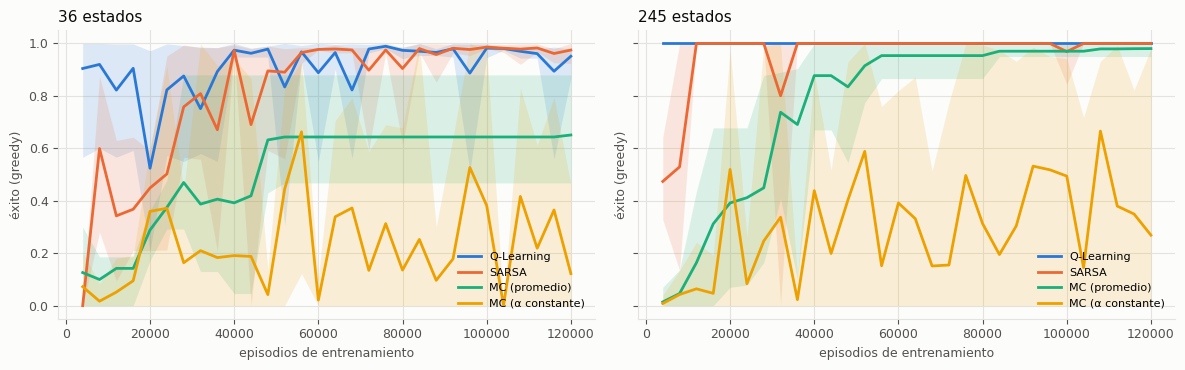

**Riesgo (ε constante 0.1, último 10 % del entrenamiento):**

| método | pérdidas ε-greedy, radio 4 m | radio 8 m | éxito ε-greedy 4 m | 8 m |
|---|---|---|---|---|
| Q-Learning | 0.5 % | 0.4 % | 91.6 % [90.6, 92.5] | 91.1 % [90.3, 91.8] |
| SARSA | 0.4 % | 0.3 % | 91.2 % [89.7, 92.5] | 91.3 % [89.5, 93.1] |
| MC (α constante) | 5.8 % | 4.8 % | 13.1 % [12.5, 13.8] | 11.9 % [11.4, 12.4] |
| MC (promedio) | 1.0 % | 1.2 % | 76.4 % [71.2, 81.3] | 67.5 % [61.8, 73.5] |

In [9]:
def row(name, v="default"):
    s = summary[name]; x = s["variants"][v]
    return f"{ci(x['last5_mean'])} | {ci(x['last5_worst'])}"
rows = ["| método | 36 estados: media últ. 5 | peor últ. 5 | 245 estados: media últ. 5 | peor últ. 5 |", "|---|---|---|---|---|"]
for m in COLS:
    rows.append(f"| {METHOD_ES[m]} | {row(f'dribbling_diag_rep_default_{m}')} | {row(f'dribbling_diag_rep_fine_{m}')} |")
display(Markdown("**Agregación (120 000 episodios, ε decreciente):**\n\n" + "\n".join(rows)))
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), sharey=True)
for ax, rep, title in zip(axes, ("default", "fine"), ("36 estados", "245 estados")):
    runs = {m: load_condition(f"{DIAG}/dribbling_diag_rep_{rep}_{m}") for m in METHOD_ES}
    plots.plot_task_eval_curves(runs, "default", ax=ax, labels=METHOD_ES, ylabel="éxito (greedy)", title=title)
fig.tight_layout(); fig.savefig(f"{ART}/fig_dribbling_aliasing.png", dpi=150, bbox_inches="tight"); plt.show()

def lost_online(path, n):
    runs = load_condition(path); tail = n // 10
    return np.mean([np.isin(r["history"]["outcome"][-tail:], [de.LOST, de.OUT]).mean() for r in runs])
rows = ["| método | pérdidas ε-greedy, radio 4 m | radio 8 m | éxito ε-greedy 4 m | 8 m |", "|---|---|---|---|---|"]
for m in COLS:
    base, diag = f"dribbling_{m}_eps_const_0.1", f"dribbling_diag_loss8_{m}"
    rows.append(f"| {METHOD_ES[m]} | {pct(lost_online(f'{RUNS}/{base}', summary[base]['n_episodes']))} | "
                f"{pct(lost_online(f'{DIAG}/{diag}', summary[diag]['n_episodes']))} | "
                f"{ci(summary[base]['online_final'])} | {ci(summary[diag]['online_final'])} |")
display(Markdown("**Riesgo (ε constante 0.1, último 10 % del entrenamiento):**\n\n" + "\n".join(rows)))

## Verificación en rcssserver

Ejecución de la política greedy (Q-Learning, ε decreciente, semilla 0) en el servidor real con
`python -m src.live_tasks dribbling --episodes 10`, con los comandos literales del enunciado: `(kick 25 0)` cuando el
servidor considera el balón pateable, `(dash 80)` y `(turn ±35)`. El estado se calcula con la verdad de terreno del
entrenador. Es una verificación de ejecución, no una medida de transferencia.

In [10]:
live = json.load(open(f"{ART}/live_dribbling.json"))
k = live["kick25_free_travel_m"]
display(Markdown(f"Ciclos perdidos: {live['missed_cycles']}. Resultados: {live['outcomes']}. Un `KICK 25` del servidor "
                 f"deja al balón con una distancia de rodado libre de {k['mean']:.1f} m en promedio ({k['min']:.1f}–{k['max']:.1f} m, "
                 f"{k['n']} patadas; velocidad tras la patada / (1 − ball_decay)), frente a los 2 m del modelo."))

Ciclos perdidos: 0. Resultados: {'success': 10}. Un `KICK 25` del servidor deja al balón con una distancia de rodado libre de 13.6 m en promedio (0.8–18.1 m, 44 patadas; velocidad tras la patada / (1 − ball_decay)), frente a los 2 m del modelo.

## Figura para el informe

(a) Ablación de exploración de Q-Learning (36 estados); (b) cada semilla de Q-Learning con $\varepsilon$ constante:
la política greedy oscila; (c) agregación: media (barra) y peor (marca) de las últimas 5 evaluaciones con 36 y 245
estados (120 000 episodios, $\varepsilon$ decreciente); (d) política greedy final de Q-Learning ($\varepsilon$
decreciente, semilla 0) sobre 6 inicios.

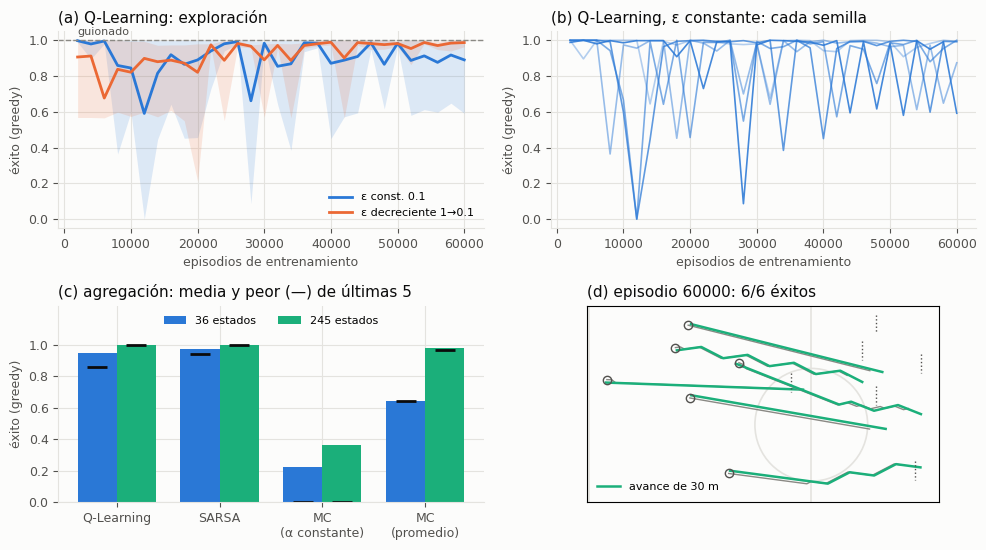

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(10, 5.6))
plots.plot_task_eval_curves(q_runs, "default", ax=axes[0, 0], labels=SCHED_ES, ylabel="éxito (greedy)",
                            refs={"guionado": 1.0}, title="(a) Q-Learning: exploración")
ax = axes[0, 1]
for i, r in enumerate(q_runs["eps_const_0.1"]):
    ax.plot([e["episode"] for e in r["evals"]], [e["variants"]["default"]["success_rate"] for e in r["evals"]],
            color=plots.SERIES[0], alpha=0.35 + 0.13 * i, linewidth=1.2)
plots.style(ax, "(b) Q-Learning, ε constante: cada semilla", "episodios de entrenamiento", "éxito (greedy)")
ax = axes[1, 0]
w = 0.38
for j, (rep, name, color) in enumerate((("default", "36 estados", plots.SERIES[0]), ("fine", "245 estados", plots.SERIES[2]))):
    means = [summary[f"dribbling_diag_rep_{rep}_{m}"]["variants"]["default"]["last5_mean"]["mean"] for m in COLS]
    worst = [summary[f"dribbling_diag_rep_{rep}_{m}"]["variants"]["default"]["last5_worst"]["mean"] for m in COLS]
    xs = np.arange(len(COLS)) + (j - 0.5) * w
    ax.bar(xs, means, width=w, color=color, label=name)
    ax.plot(xs, worst, "_", color=plots.TEXT, markersize=14, markeredgewidth=2)
ax.set_xticks(range(len(COLS)), [METHOD_ES[m].replace(" (", "\n(") for m in COLS], fontsize=8)
plots.style(ax, "(c) agregación: media y peor (—) de últimas 5", "", "éxito (greedy)")
ax.set_ylim(0, 1.25); ax.set_yticks(np.arange(0, 1.01, 0.2))
ax.legend(frameon=False, fontsize=8, loc="upper center", ncol=2)
agent = AGENTS["qlearning"](disc.n_states, 4, seed=0); agent.Q = snaps[keys[-1]].copy()
recs = [run_episode(spec, env, agent, disc, 0.0, learn=False, start=s, record=True) for s in starts]
plots.plot_dribbling_episodes(recs, ax=axes[1, 1], title=f"(d) episodio {int(keys[-1].split('_')[1])}: "
                              f"{sum(r['success'] for r in recs)}/6 éxitos")
fig.tight_layout(); fig.savefig(f"{ART}/fig_report_dribbling.png", dpi=200, bbox_inches="tight"); plt.show()

## 9. Conclusiones

Todos los números están en las tablas de arriba (IC 95 % bootstrap sobre 5 semillas; una diferencia se declara
solo si los IC no se solapan, un criterio grueso con 5 semillas).

- **Cota y criterio:** el controlador guionado logra 100 % (500 inicios de evaluación y 20 000 aleatorios; 60.4
  pasos en promedio, máximo 85 < 100). Con la media de las últimas 5 evaluaciones, Q-Learning y SARSA cumplen el
  criterio (> 80 %) en las 5 semillas con ambos esquemas de exploración; MC con promedios solo con ε decreciente
  (4 de 5 semillas); MC con α constante no lo cumple.
- **Oscilación:** aunque el entorno es determinista, la política greedy de Q-Learning y SARSA sube y baja entre
  evaluaciones (peor de las últimas 5 de Q-Learning con ε constante: 71.6 %). Las caídas son timeouts (pérdidas
  ≈ 0 %): ciclos `TURN +35` / `TURN −35` entre estados agregados con valores casi empatados.
- **Agregación de estados (diagnóstico):** con 245 estados y el mismo presupuesto, Q-Learning y SARSA llegan a
  100 % en las 5 semillas y en cada una de las últimas 5 evaluaciones, frente a 95.1 % y 97.6 % con 36 estados
  (peor de las últimas 5: 86.0 % y 94.0 %), con IC separados. La oscilación viene de la agregación, no del
  presupuesto: la representación de 36 estados es demasiado gruesa para esta tarea.
- **Exploración (Q-Learning):** con α elegido para cada esquema, ε decreciente termina mejor que ε constante (media
  de las últimas 5: 97.7 % frente a 89.7 %; peor: 94.2 % frente a 71.6 %; IC separados). ε constante aprende antes
  (su retorno de entrenamiento se estabiliza en ~3 000 episodios; con ε decreciente, en ~35 000), pero su política
  greedy oscila más. En SARSA no hay diferencia detectable al final, pero con ε decreciente aprende mucho más lento
  (AUC 76.2 % frente a 96.1 %): mientras ε es alto, SARSA estima el valor de una política casi aleatoria, en cambio
  Q-Learning (off-policy) aprende la política greedy desde el principio.
- **Q-Learning frente a SARSA:** con ε constante, SARSA es más estable (media de las últimas 5: 96.8 % frente a
  89.7 %; peor: 92.7 % frente a 71.6 %; IC separados). Parte de la diferencia puede venir de α (el barrido eligió
  0.03 para SARSA y 0.1 para Q-Learning); con α = 0.03 para ambos, el barrido (semillas 5–9) dio 91 % y 96 %.
- **Riesgo (hipótesis H2): no observado.** Durante la exploración, Q-Learning y SARSA pierden el balón en ≤ 0.5 %
  de los episodios; las fallas son timeouts, y con radio de pérdida de 8 m nada cambia. En la conducción no hay un
  "acantilado" relevante: una acción aleatoria rara vez aleja el balón 4 m.
- **MC con promedios (hipótesis H3, robustez a la agregación): contradicha.** Es el método más afectado por la
  representación gruesa (64.5 % con 36 estados y 120 000 episodios) y el que más gana con la fina (97.8 %). Con
  36 estados no oscila: su política se congela (curvas planas; media y peor de las últimas 5 casi iguales, 64.5 %
  y 64.3 %). Es coherente con el paso 1/N, que mantiene con peso completo los retornos de políticas anteriores y
  peores, pero ese mecanismo no lo aislamos con un experimento.
- **MC con α constante:** falla en todas las condiciones, también con 245 estados. Mejora al bajar α (media de las
  últimas 5: 30 % con α = 0.03, 34 % con 0.01, 53 % con 0.003) sin llegar al criterio; con ε constante, el 81 % de sus
  episodios de entrenamiento terminan por timeout. La causa no está aislada. Es el mismo patrón que en la persecución (34 %) y
  lo contrario que en el tiro a puerta, donde los episodios duran un paso.